In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import sklearn.model_selection
from sklearn.linear_model import LogisticRegression
import sklearn.metrics
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [51]:
df = pd.read_csv("C:/Users/mutch_lf652j0/Credit Score Interactive Model/data/raw/loan_book.csv")

In [52]:
df.head()

,applicant_id_hash,age,annual_income,employment_length_years,home_ownership,region,num_open_accounts,num_delinquencies_2yr,total_revolving_balance,credit_utilisation_pct,...,months_since_last_delinquency,pct_accounts_current,application_date,application_dow,branch_code_id,months_at_current_address,email_domain_type,phone_verified,default_flag,set
0,11a2f242b28a331c,35.5,29401.0,3.6,MORTGAGE,North-Urban,9.0,7,1778.0,12.7,...,1.0,50.9,06/14/2021,Monday,347,119,other,True,0,test
1,5afff059dc04c6f0,25.0,32005.0,1.4,mortgage,South-Urban,10.0,0,0.0,31.2,...,105.0,93.0,2021-08-28,Friday,367,7,free,False,0,train
2,eb85b183be0505f3,40.0,26730.0,NaN,MORTGAGE,East-Urban,9.0,0,3690.0,29.4,...,NaN,87.9,2021-02-23,Saturday,895,142,free,True,0,test
3,7d99629563bdb528,30.9,60105.0,7.5,MORTGAGE,South-Suburban,7.0,0,7636.0,48.8,...,58.0,96.1,2021-10-07,Thursday,387,69,other,True,1,test
4,658f1f05e484ce14,49.1,112275.0,6.9,MORTGAGE,East-Suburban,10.0,0,14450.0,68.2,...,NaN,90.8,23-Aug-2021,Sunday,561,182,free,True,0,test


In [53]:
def wrangle(filepath):



    return df

In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120960 entries, 0 to 120959
Data columns (total 26 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   applicant_id_hash              120960 non-null  str    
 1   age                            120960 non-null  float64
 2   annual_income                  112269 non-null  float64
 3   employment_length_years        117236 non-null  float64
 4   home_ownership                 120960 non-null  str    
 5   region                         120960 non-null  str    
 6   num_open_accounts              118523 non-null  float64
 7   num_delinquencies_2yr          120960 non-null  int64  
 8   total_revolving_balance        120960 non-null  float64
 9   credit_utilisation_pct         120960 non-null  float64
 10  months_since_oldest_account    120960 non-null  float64
 11  num_hard_inquiries_6mo         120960 non-null  int64  
 12  loan_amount                    120960 non

In [55]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,120960.0,38.422239,11.134891,21.00,29.900,38.000,46.100,70.000
annual_income,112269.0,68335.260580,96804.044444,2909.00,34720.000,52490.000,79109.000,2000000.000
employment_length_years,117236.0,5.997114,4.107016,0.00,3.100,5.400,8.200,30.400
num_open_accounts,118523.0,8.005695,2.827295,0.00,6.000,8.000,10.000,23.000
num_delinquencies_2yr,120960.0,0.822487,1.243282,0.00,0.000,0.000,2.000,9.000
total_revolving_balance,120960.0,4475.490038,4257.888475,0.00,1123.000,3688.000,6591.000,63715.000
credit_utilisation_pct,120960.0,41.648566,19.270326,0.00,27.200,40.700,55.300,106.200
months_since_oldest_account,120960.0,177.514534,84.155915,9.00,114.000,174.000,235.000,537.000
num_hard_inquiries_6mo,120960.0,1.498562,1.223993,0.00,1.000,1.000,2.000,10.000
loan_amount,120960.0,12028.900562,18068.727874,1387.00,7516.000,10104.000,13634.000,497213.000


In [56]:
#Lets start by cleaning the train and test set using operations we can perform on both without data leakage.

In [57]:
df.duplicated().sum()

np.int64(602)

In [58]:
duplicated = df[df.duplicated(keep = False)]
duplicated.head(20)

,applicant_id_hash,age,annual_income,employment_length_years,home_ownership,region,num_open_accounts,num_delinquencies_2yr,total_revolving_balance,credit_utilisation_pct,...,months_since_last_delinquency,pct_accounts_current,application_date,application_dow,branch_code_id,months_at_current_address,email_domain_type,phone_verified,default_flag,set
117,e1427d0c69c33656,41.2,46121.0,5.6,MORTGAGE,North-Urban,4.0,2,4021.0,39.2,...,1.0,88.2,2021-03-06,Wednesday,894,226,corporate,True,0,test
246,004af95b4c6d5dd3,27.3,14393.0,1.3,MORTGAGE,West-Urban,5.0,0,4008.0,35.9,...,NaN,41.7,2022-07-13,Saturday,622,32,corporate,True,0,train
307,a6798fca904c4b98,53.8,75836.0,1.1,OWN,Central-Urban,5.0,0,4201.0,43.0,...,NaN,66.0,2021-09-09,Sunday,807,58,free,True,0,train
329,f3be880f4de02ac0,47.4,91259.0,4.9,MORTGAGE,South-Urban,11.0,0,1612.0,19.0,...,NaN,79.3,2023-11-12,Tuesday,530,5,free,True,0,test
414,73278ed10c82d542,33.6,NaN,NaN,MORTGAGE,East-Suburban,4.0,0,10931.0,36.0,...,25.0,97.9,2023-05-28,Friday,121,66,other,True,0,train
561,0cccdb178d8734eb,56.8,81934.0,8.7,RENT,South-Suburban,5.0,0,6408.0,35.2,...,NaN,92.0,2023-10-14,Monday,693,87,corporate,True,0,train
763,ef8dc6ff6054db73,52.4,45506.0,6.8,MORTGAGE,Central-Suburban,6.0,0,0.0,29.5,...,NaN,90.8,11/04/2022,Saturday,642,126,free,True,0,train
962,e86e11a20fd090dd,35.6,25397.0,0.0,RENT,South-Suburban,9.0,0,5829.0,45.1,...,NaN,98.2,2023-10-02,Friday,828,223,corporate,False,0,train
965,aa720f8bbc083943,43.6,22746.0,2.5,RENT,East-Suburban,9.0,2,1313.0,28.4,...,1.0,66.8,2022-12-08,Tuesday,998,167,free,True,1,train
1023,89fe4758f4db3433,30.4,75206.0,2.3,MORTGAGE,North-Urban,7.0,1,11018.0,29.9,...,34.0,93.8,2023-04-28,Friday,292,77,free,True,0,train


In [59]:
#Before we drop duplicates, lets ensure our application_date column is in one consistent format so that we dont miss any duplicates.

In [60]:
df["application_date"] = pd.to_datetime(df["application_date"], format = "mixed")
df = df.drop_duplicates()

In [61]:
df.info()

<class 'pandas.DataFrame'>
Index: 120358 entries, 0 to 120959
Data columns (total 26 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   applicant_id_hash              120358 non-null  str           
 1   age                            120358 non-null  float64       
 2   annual_income                  111720 non-null  float64       
 3   employment_length_years        116647 non-null  float64       
 4   home_ownership                 120358 non-null  str           
 5   region                         120358 non-null  str           
 6   num_open_accounts              117935 non-null  float64       
 7   num_delinquencies_2yr          120358 non-null  int64         
 8   total_revolving_balance        120358 non-null  float64       
 9   credit_utilisation_pct         120358 non-null  float64       
 10  months_since_oldest_account    120358 non-null  float64       
 11  num_hard_inquiri

In [62]:
# Now that we have removed duplicates, lets handle missing values.  

In [63]:
df.isnull().sum()

applicant_id_hash                    0
age                                  0
annual_income                     8638
employment_length_years           3711
home_ownership                       0
region                               0
num_open_accounts                 2423
num_delinquencies_2yr                0
total_revolving_balance              0
credit_utilisation_pct               0
months_since_oldest_account          0
num_hard_inquiries_6mo               0
loan_amount                          0
interest_rate                        0
loan_purpose                         0
dti_ratio                            0
months_since_last_delinquency    60068
pct_accounts_current                 0
application_date                     0
application_dow                      0
branch_code_id                       0
months_at_current_address            0
email_domain_type                    0
phone_verified                       0
default_flag                         0
set                      

In [64]:
# We will use bucketwise imputation to fill in missing values. Lets start by checking the matrix correlation to identify how to fill in missing values.

In [65]:
df_numeric = df.select_dtypes(include = np.number)
df_numeric.head()

,age,annual_income,employment_length_years,num_open_accounts,num_delinquencies_2yr,total_revolving_balance,credit_utilisation_pct,months_since_oldest_account,num_hard_inquiries_6mo,loan_amount,interest_rate,dti_ratio,months_since_last_delinquency,pct_accounts_current,branch_code_id,months_at_current_address,default_flag
0,35.5,29401.0,3.6,9.0,7,1778.0,12.7,177.0,2,16326.0,21.11,0.245,1.0,50.9,347,119,0
1,25.0,32005.0,1.4,10.0,0,0.0,31.2,42.0,1,8293.0,12.69,0.337,105.0,93.0,367,7,0
2,40.0,26730.0,NaN,9.0,0,3690.0,29.4,148.0,0,13080.0,10.45,0.124,NaN,87.9,895,142,0
3,30.9,60105.0,7.5,7.0,0,7636.0,48.8,115.0,2,6752.0,15.26,0.218,58.0,96.1,387,69,1
4,49.1,112275.0,6.9,10.0,0,14450.0,68.2,324.0,3,19144.0,9.04,0.195,NaN,90.8,561,182,0


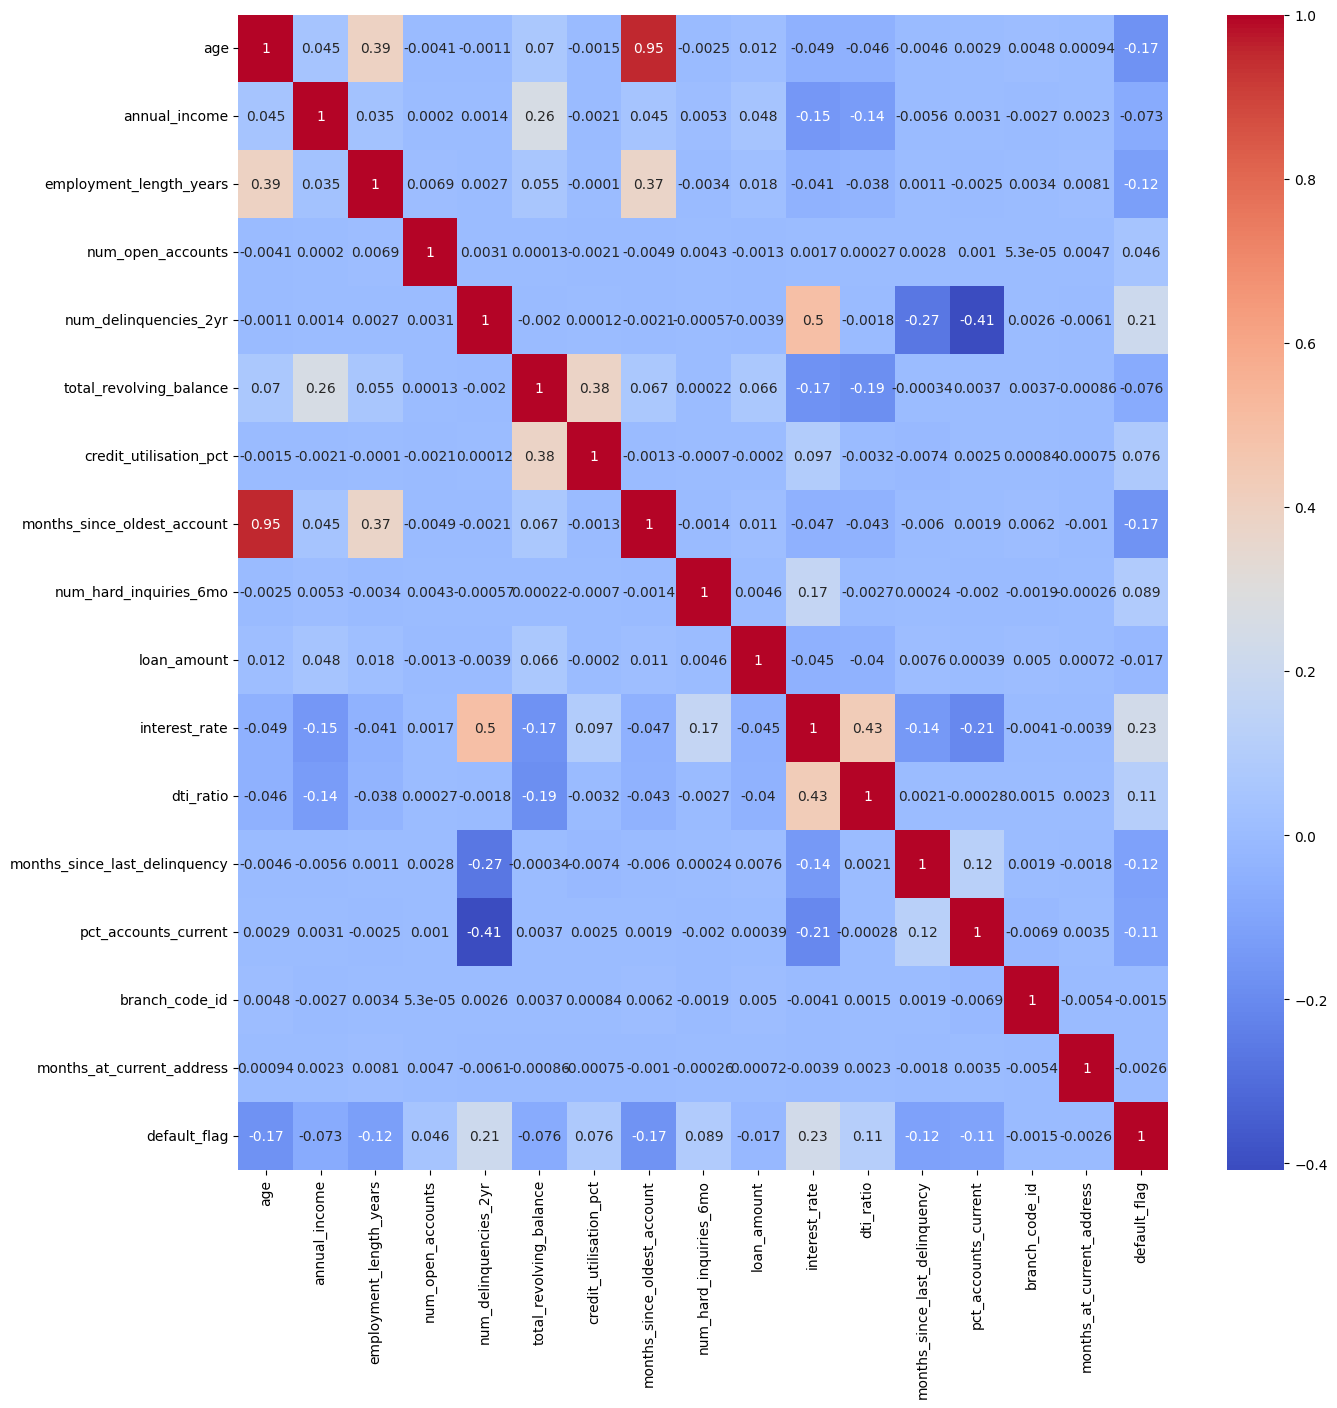

In [66]:
plt.figure(figsize = (15,15))
sns.heatmap(df_numeric.corr(), annot=True, cmap = "coolwarm")
plt.show()

In [67]:
df["missing_annual_income"] = df["annual_income"].isnull().astype(int)
df.groupby("missing_annual_income")["default_flag"].mean()

missing_annual_income
0    0.150895
1    0.199236
Name: default_flag, dtype: float64

In [68]:
print(df_numeric.columns.tolist())
print(df.select_dtypes(include = "object").columns.tolist())


['age', 'annual_income', 'employment_length_years', 'num_open_accounts', 'num_delinquencies_2yr', 'total_revolving_balance', 'credit_utilisation_pct', 'months_since_oldest_account', 'num_hard_inquiries_6mo', 'loan_amount', 'interest_rate', 'dti_ratio', 'months_since_last_delinquency', 'pct_accounts_current', 'branch_code_id', 'months_at_current_address', 'default_flag']
['applicant_id_hash', 'home_ownership', 'region', 'loan_purpose', 'application_dow', 'email_domain_type', 'set']


C:\Users\mutch_lf652j0\AppData\Local\Temp\ipykernel_23680\3419358934.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include = "object").columns.tolist())


In [69]:
df.groupby("missing_annual_income")[['age', 'annual_income', 'employment_length_years', 'num_open_accounts', 'num_delinquencies_2yr',
         'total_revolving_balance', 'credit_utilisation_pct', 'months_since_oldest_account', 'num_hard_inquiries_6mo', 'loan_amount', 'interest_rate',
  'dti_ratio', 'months_since_last_delinquency', 'pct_accounts_current', 'branch_code_id', 'months_at_current_address', 'default_flag']].mean()

,age,annual_income,employment_length_years,num_open_accounts,num_delinquencies_2yr,total_revolving_balance,credit_utilisation_pct,months_since_oldest_account,num_hard_inquiries_6mo,loan_amount,interest_rate,dti_ratio,months_since_last_delinquency,pct_accounts_current,branch_code_id,months_at_current_address,default_flag
missing_annual_income,,,,,,,,,,,,,,,,,
0,38.660475,68335.158029,6.131130,8.005874,0.823881,4488.458870,41.642402,179.197709,1.497682,12035.995516,11.999027,0.204981,23.922539,80.644897,549.823971,120.190064,0.150895
1,35.297870,NaN,4.259821,8.001063,0.806437,4297.167284,41.724311,155.472910,1.505788,11985.089257,12.079784,0.207453,23.343735,80.694119,548.000579,119.238713,0.199236


In [70]:
df.groupby("missing_annual_income")[['home_ownership', 'region', 'loan_purpose', 'application_dow', 'email_domain_type']].value_counts()

missing_annual_income  home_ownership  region          loan_purpose        application_dow  email_domain_type
0                      MORTGAGE        North-Urban     debt_consolidation  Tuesday          free                 130
                                       West-Urban      debt_consolidation  Wednesday        free                 129
                                       South-Urban     debt_consolidation  Friday           free                 128
                                       South-Suburban  debt_consolidation  Wednesday        free                 128
                                       West-Suburban   debt_consolidation  Thursday         free                 126
                                                                                                                ... 
1                      Mortgage        North-Urban     debt_consolidation  Thursday         corporate              1
                       mortgage        North-Suburban  education       

In [71]:
# the most significant difference in missing income is employment length, lets impute missing income based on employment length buckets.  

In [72]:
df['annual_income'] = df.groupby(pd.cut(df['employment_length_years'], bins = 5))['annual_income'].transform(lambda x: x.fillna(x.median()))  
df.isnull().sum()

applicant_id_hash                    0
age                                  0
annual_income                     3711
employment_length_years           3711
home_ownership                       0
region                               0
num_open_accounts                 2423
num_delinquencies_2yr                0
total_revolving_balance              0
credit_utilisation_pct               0
months_since_oldest_account          0
num_hard_inquiries_6mo               0
loan_amount                          0
interest_rate                        0
loan_purpose                         0
dti_ratio                            0
months_since_last_delinquency    60068
pct_accounts_current                 0
application_date                     0
application_dow                      0
branch_code_id                       0
months_at_current_address            0
email_domain_type                    0
phone_verified                       0
default_flag                         0
set                      

In [73]:
df["annual_income"] = df["annual_income"].fillna(df["annual_income"].median())
df.isnull().sum()

applicant_id_hash                    0
age                                  0
annual_income                        0
employment_length_years           3711
home_ownership                       0
region                               0
num_open_accounts                 2423
num_delinquencies_2yr                0
total_revolving_balance              0
credit_utilisation_pct               0
months_since_oldest_account          0
num_hard_inquiries_6mo               0
loan_amount                          0
interest_rate                        0
loan_purpose                         0
dti_ratio                            0
months_since_last_delinquency    60068
pct_accounts_current                 0
application_date                     0
application_dow                      0
branch_code_id                       0
months_at_current_address            0
email_domain_type                    0
phone_verified                       0
default_flag                         0
set                      

In [74]:
#lets check if missing employment length is also a significant factor in default rate.

In [75]:
df["missing_employment_length"] = df["employment_length_years"].isnull().astype(int)
df.groupby("missing_employment_length")["default_flag"].mean()

missing_employment_length
0    0.154063
1    0.163837
Name: default_flag, dtype: float64

In [76]:
#No signifant difference in determining default rate, so we will impute missing employment length with age,since they have a 0.39 correlation and makes sense logically.

In [77]:
df["employment_length_years"] = df.groupby(pd.cut(df["age"], bins = 5))["employment_length_years"].transform(lambda x: x.fillna(x.median()))

df.isnull().sum()

applicant_id_hash                    0
age                                  0
annual_income                        0
employment_length_years              0
home_ownership                       0
region                               0
num_open_accounts                 2423
num_delinquencies_2yr                0
total_revolving_balance              0
credit_utilisation_pct               0
months_since_oldest_account          0
num_hard_inquiries_6mo               0
loan_amount                          0
interest_rate                        0
loan_purpose                         0
dti_ratio                            0
months_since_last_delinquency    60068
pct_accounts_current                 0
application_date                     0
application_dow                      0
branch_code_id                       0
months_at_current_address            0
email_domain_type                    0
phone_verified                       0
default_flag                         0
set                      

In [78]:
#now we will do the same for num_open_accounts.  

In [79]:
df["missing_num_open_accounts"] = df["num_open_accounts"].isnull().astype(int)
df.groupby("missing_num_open_accounts")["default_flag"].mean()

missing_num_open_accounts
0    0.154161
1    0.164259
Name: default_flag, dtype: float64

In [80]:
df["num_open_accounts"] = df["num_open_accounts"].fillna(df["num_open_accounts"].median())
df.isnull().sum()

applicant_id_hash                    0
age                                  0
annual_income                        0
employment_length_years              0
home_ownership                       0
region                               0
num_open_accounts                    0
num_delinquencies_2yr                0
total_revolving_balance              0
credit_utilisation_pct               0
months_since_oldest_account          0
num_hard_inquiries_6mo               0
loan_amount                          0
interest_rate                        0
loan_purpose                         0
dti_ratio                            0
months_since_last_delinquency    60068
pct_accounts_current                 0
application_date                     0
application_dow                      0
branch_code_id                       0
months_at_current_address            0
email_domain_type                    0
phone_verified                       0
default_flag                         0
set                      

In [81]:
df["missing_months_since_last_delinquency"] = df["months_since_last_delinquency"].isnull().astype(int)
df.groupby("missing_months_since_last_delinquency")["default_flag"].mean()

missing_months_since_last_delinquency
0    0.228943
1    0.079510
Name: default_flag, dtype: float64

In [82]:
#This means that most applicants who have a missing value for months_since_last_delinquent have never defaulted. We will use this as one of our features.

In [83]:
#Given the large distinction in default rate with those with no missing value for months_since_last_delinquency = 22.89% and those with missing value = 7.95%, we will fill missing values with a very large number.

In [84]:
df["months_since_last_delinquency"] = df["months_since_last_delinquency"].fillna(900)
df.isnull().sum()

applicant_id_hash                        0
age                                      0
annual_income                            0
employment_length_years                  0
home_ownership                           0
region                                   0
num_open_accounts                        0
num_delinquencies_2yr                    0
total_revolving_balance                  0
credit_utilisation_pct                   0
months_since_oldest_account              0
num_hard_inquiries_6mo                   0
loan_amount                              0
interest_rate                            0
loan_purpose                             0
dti_ratio                                0
months_since_last_delinquency            0
pct_accounts_current                     0
application_date                         0
application_dow                          0
branch_code_id                           0
months_at_current_address                0
email_domain_type                        0
phone_verif

In [85]:
""" So our most notable findings so far are missing values for months since last delinquency is a significan factor in determining default rate,
with no missing value indicating a higher risk of default, there is also a 5% difference in default rate between missing annual income."""

' So our most notable findings so far are missing values for months since last delinquency is a significan factor in determining default rate,\nwith no missing value indicating a higher risk of default, there is also a 5% difference in default rate between missing annual income.'

In [86]:
df.info()

<class 'pandas.DataFrame'>
Index: 120358 entries, 0 to 120959
Data columns (total 30 columns):
 #   Column                                 Non-Null Count   Dtype         
---  ------                                 --------------   -----         
 0   applicant_id_hash                      120358 non-null  str           
 1   age                                    120358 non-null  float64       
 2   annual_income                          120358 non-null  float64       
 3   employment_length_years                120358 non-null  float64       
 4   home_ownership                         120358 non-null  str           
 5   region                                 120358 non-null  str           
 6   num_open_accounts                      120358 non-null  float64       
 7   num_delinquencies_2yr                  120358 non-null  int64         
 8   total_revolving_balance                120358 non-null  float64       
 9   credit_utilisation_pct                 120358 non-null  float64 

In [87]:
#lets check for any invalid values 

In [88]:
numeric_cols = df.select_dtypes(include='number').columns
(df[numeric_cols] < 0).sum()

age                                      0
annual_income                            0
employment_length_years                  0
num_open_accounts                        0
num_delinquencies_2yr                    0
total_revolving_balance                  0
credit_utilisation_pct                   0
months_since_oldest_account              0
num_hard_inquiries_6mo                   0
loan_amount                              0
interest_rate                            0
dti_ratio                                0
months_since_last_delinquency            0
pct_accounts_current                     0
branch_code_id                           0
months_at_current_address                0
default_flag                             0
missing_annual_income                    0
missing_employment_length                0
missing_num_open_accounts                0
missing_months_since_last_delinquency    0
dtype: int64

In [89]:
df["applicant_id_hash"].nunique()

120000

In [90]:
df[df["applicant_id_hash"].duplicated(keep = False)].sort_values("applicant_id_hash").head(20)

,applicant_id_hash,age,annual_income,employment_length_years,home_ownership,region,num_open_accounts,num_delinquencies_2yr,total_revolving_balance,credit_utilisation_pct,...,branch_code_id,months_at_current_address,email_domain_type,phone_verified,default_flag,set,missing_annual_income,missing_employment_length,missing_num_open_accounts,missing_months_since_last_delinquency
72664,00817873424f43a2,45.8,23493.0,4.5,RENT,North-Suburban,14.0,0,457.0,35.0,...,251,102,corporate,True,0,train,0,0,0,1
101581,00817873424f43a2,45.8,23493.0,4.5,RENT,North-Suburban,14.0,0,457.0,35.0,...,251,102,corporate,True,0,train,0,0,0,1
27690,0099acd6b393b0d9,64.4,137408.0,9.2,RENT,West-Urban,12.0,0,4577.0,17.5,...,820,144,free,True,0,train,0,0,0,0
107999,0099acd6b393b0d9,64.4,137408.0,9.2,RENT,West-Urban,12.0,0,4577.0,17.5,...,820,144,free,True,0,train,0,0,0,0
84679,01214f929812537b,43.1,53138.0,7.0,RENT,West-Suburban,9.0,0,1365.0,23.1,...,235,127,free,True,0,train,0,0,0,0
115172,01214f929812537b,43.1,53138.0,7.0,RENT,West-Suburban,9.0,0,1365.0,23.1,...,235,127,free,True,0,train,0,0,0,0
107688,016f4cc3c08ca36c,45.8,52788.0,4.8,OWN,East-Urban,9.0,0,3315.0,26.3,...,464,103,free,True,0,train,0,0,0,1
45636,016f4cc3c08ca36c,45.8,52788.0,4.8,OWN,East-Urban,9.0,0,3315.0,26.3,...,464,103,free,True,0,train,0,0,0,1
17804,0243890841ea14eb,39.5,52793.0,9.4,MORTGAGE,East-Suburban,7.0,4,0.0,53.3,...,893,134,other,True,1,train,0,0,0,0
34940,0243890841ea14eb,39.5,52793.0,9.4,MORTGAGE,East-Suburban,7.0,4,0.0,53.3,...,893,134,other,True,1,train,0,0,0,0


In [91]:
df['applicant_id_hash'].value_counts()[df['applicant_id_hash'].value_counts() > 1]

applicant_id_hash
d592f6e1cef2d3e3    2
374fcf8ab45b3a65    2
acf92360894ea35d    2
f5cd0f03d32aba68    2
0ad597f33b4a2c8a    2
                   ..
392f9e67555996be    2
b381ced38675edf6    2
fa3f6cc82ea1ebbb    2
4330cded8c193fc3    2
0e3b71043dfd4066    2
Name: count, Length: 358, dtype: int64

In [92]:
df = df.drop(columns = ["applicant_id_hash"])

In [93]:
df["home_ownership"].nunique()

14

In [94]:
categorical_cols = df.select_dtypes(include = "object").columns
for col in categorical_cols:
    df[col] = df[col].astype("category").cat.codes


C:\Users\mutch_lf652j0\AppData\Local\Temp\ipykernel_23680\1663915079.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include = "object").columns


In [95]:
df.head()

,age,annual_income,employment_length_years,home_ownership,region,num_open_accounts,num_delinquencies_2yr,total_revolving_balance,credit_utilisation_pct,months_since_oldest_account,...,branch_code_id,months_at_current_address,email_domain_type,phone_verified,default_flag,set,missing_annual_income,missing_employment_length,missing_num_open_accounts,missing_months_since_last_delinquency
0,35.5,29401.0,3.6,0,5,9.0,7,1778.0,12.7,177.0,...,347,119,2,True,0,0,0,0,0,0
1,25.0,32005.0,1.4,10,7,10.0,0,0.0,31.2,42.0,...,367,7,1,False,0,1,0,0,0,0
2,40.0,51300.0,5.0,0,3,9.0,0,3690.0,29.4,148.0,...,895,142,1,True,0,0,0,1,0,1
3,30.9,60105.0,7.5,0,6,7.0,0,7636.0,48.8,115.0,...,387,69,2,True,1,0,0,0,0,0
4,49.1,112275.0,6.9,0,2,10.0,0,14450.0,68.2,324.0,...,561,182,1,True,0,0,0,0,0,1


In [99]:
df.info()

<class 'pandas.DataFrame'>
Index: 120358 entries, 0 to 120959
Data columns (total 29 columns):
 #   Column                                 Non-Null Count   Dtype         
---  ------                                 --------------   -----         
 0   age                                    120358 non-null  float64       
 1   annual_income                          120358 non-null  float64       
 2   employment_length_years                120358 non-null  float64       
 3   home_ownership                         120358 non-null  int8          
 4   region                                 120358 non-null  int8          
 5   num_open_accounts                      120358 non-null  float64       
 6   num_delinquencies_2yr                  120358 non-null  int64         
 7   total_revolving_balance                120358 non-null  float64       
 8   credit_utilisation_pct                 120358 non-null  float64       
 9   months_since_oldest_account            120358 non-null  float64 

In [107]:
exclude_cols = ["default_flag", "set", "application_date", "missing_annual_income", "missing_employment_length", "missing_num_open_accounts", "missing_months_since_last_delinquency"]

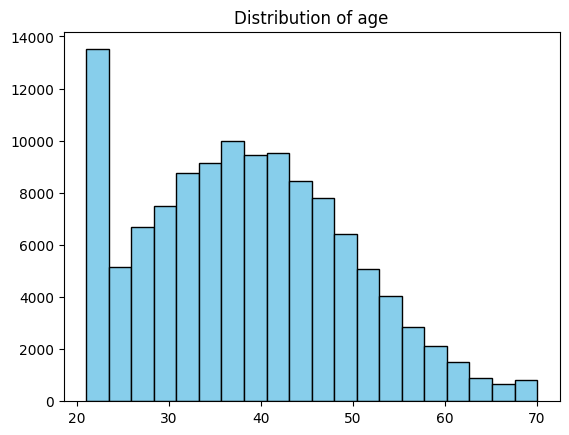

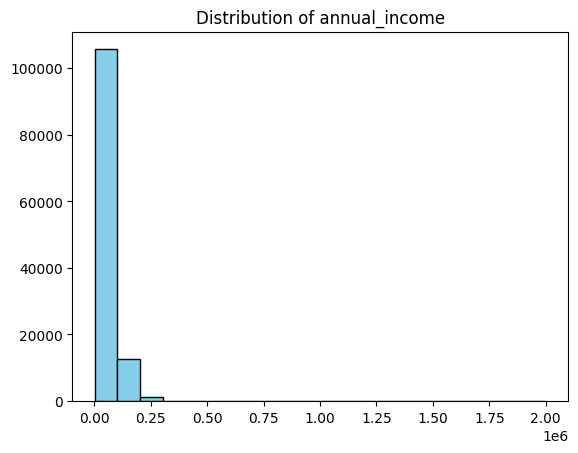

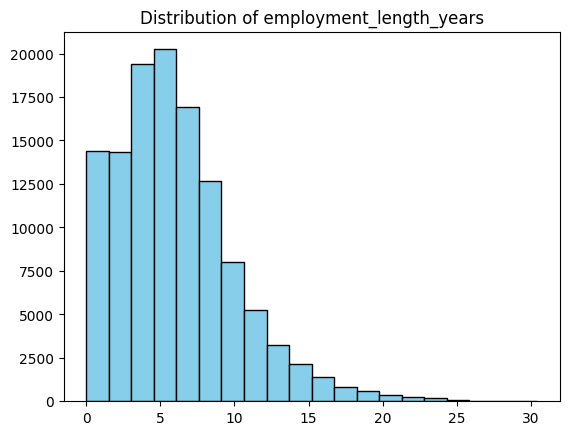

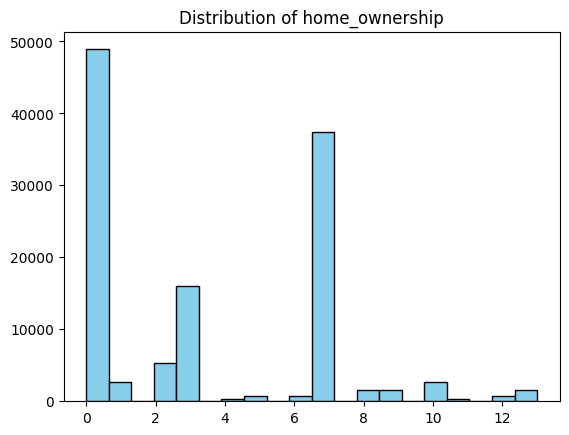

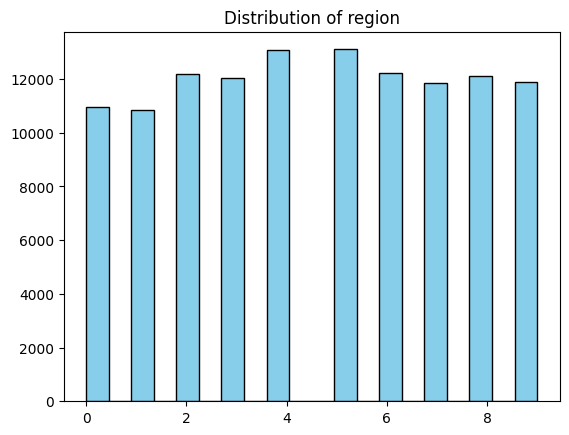

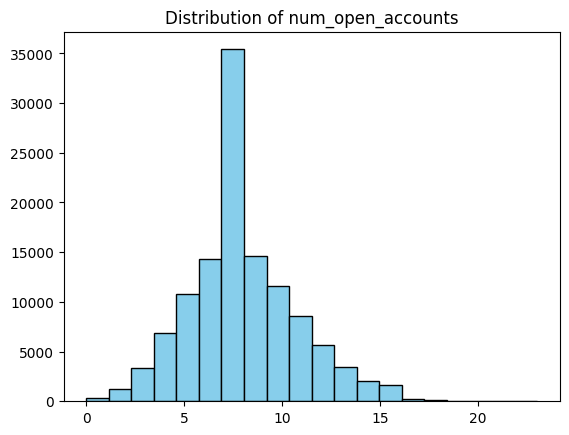

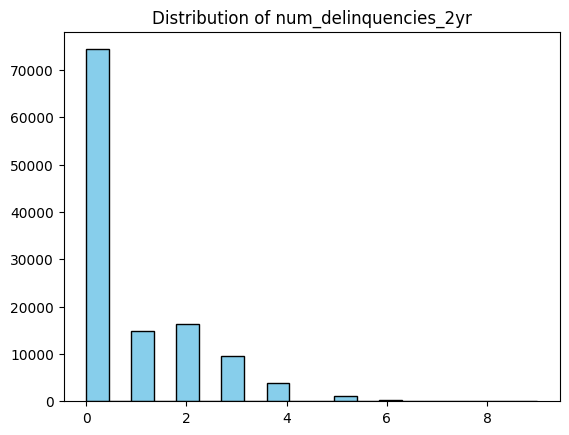

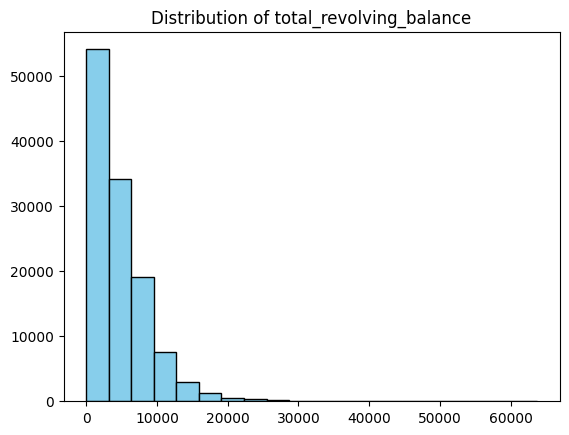

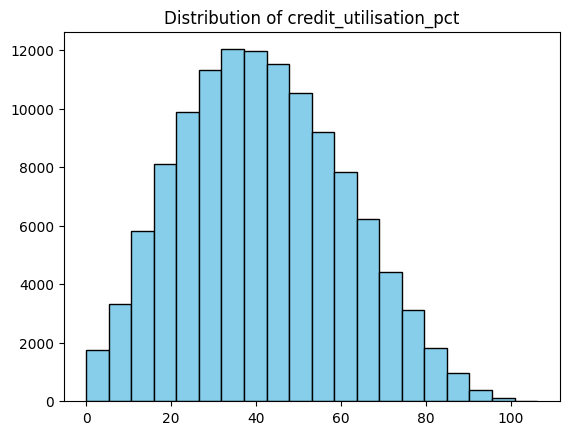

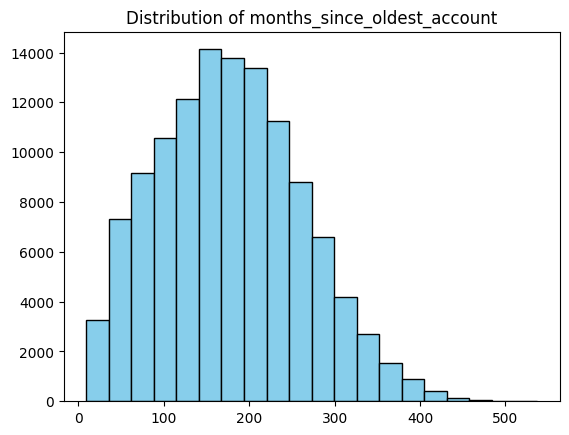

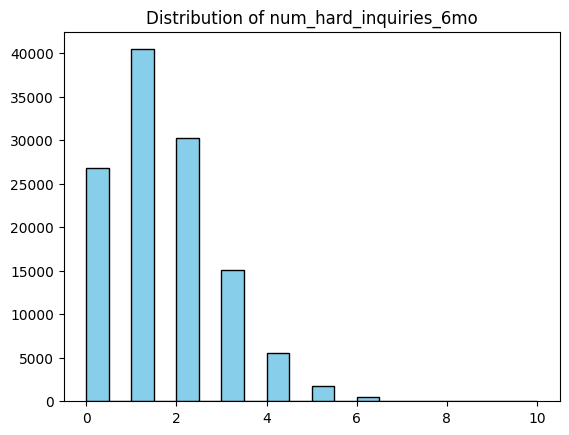

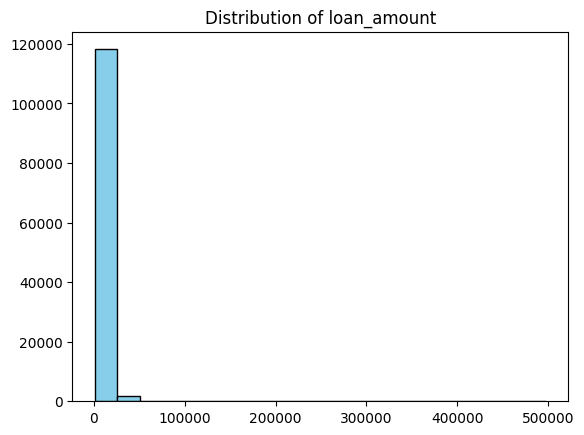

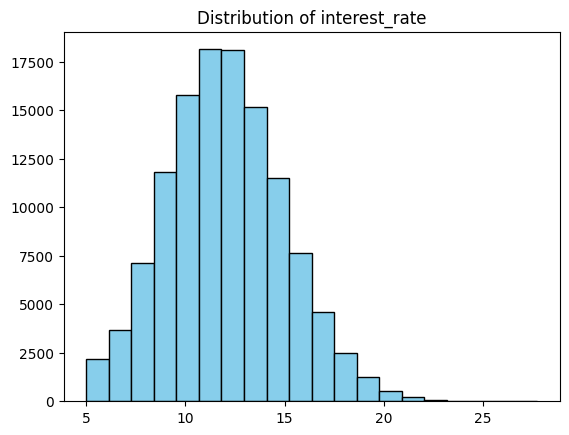

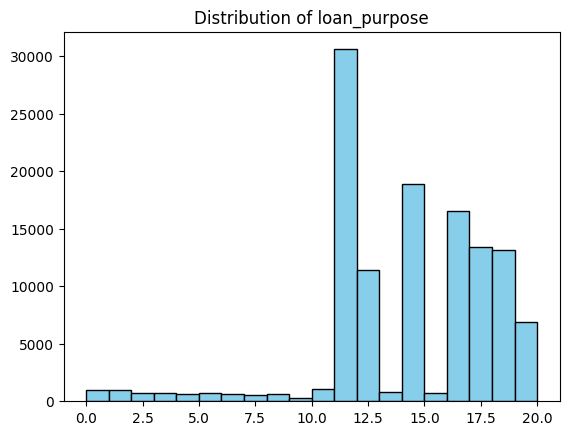

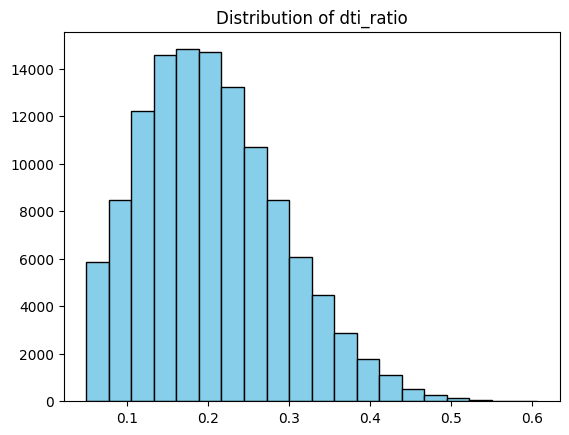

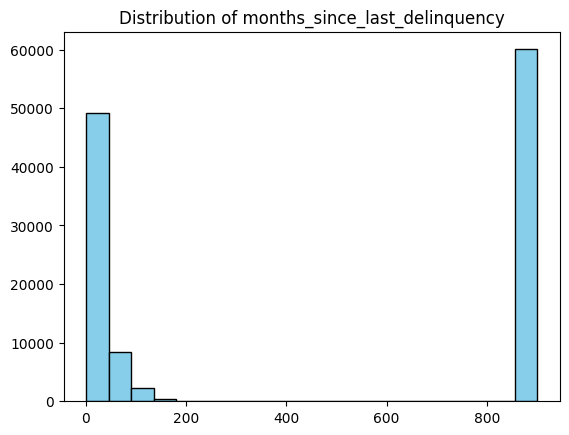

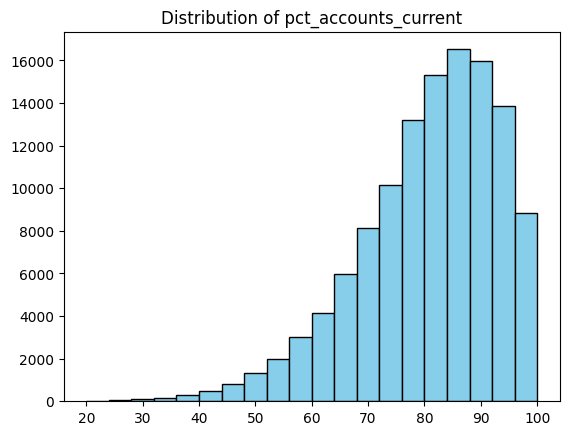

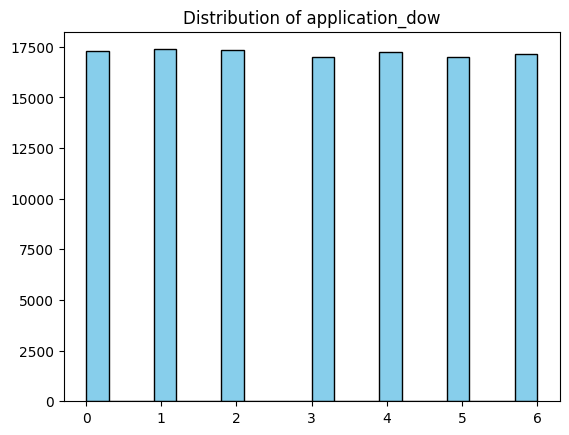

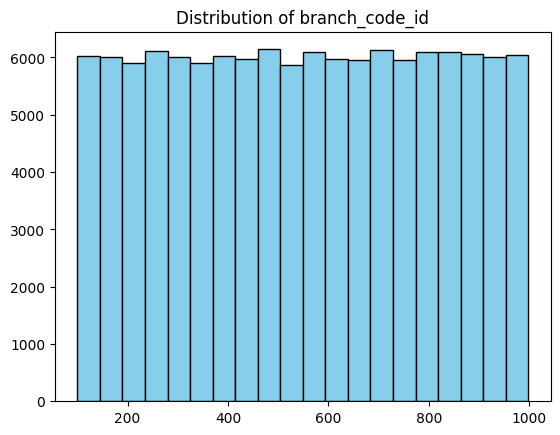

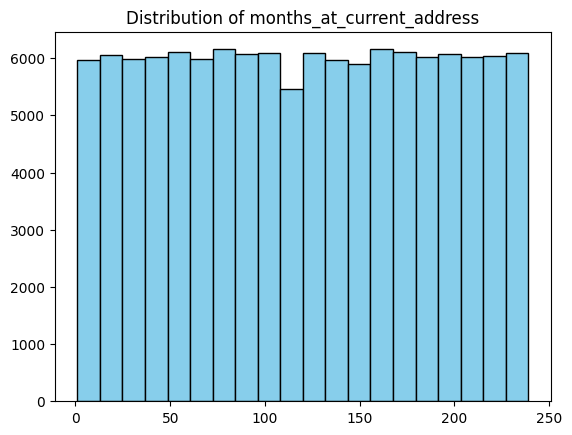

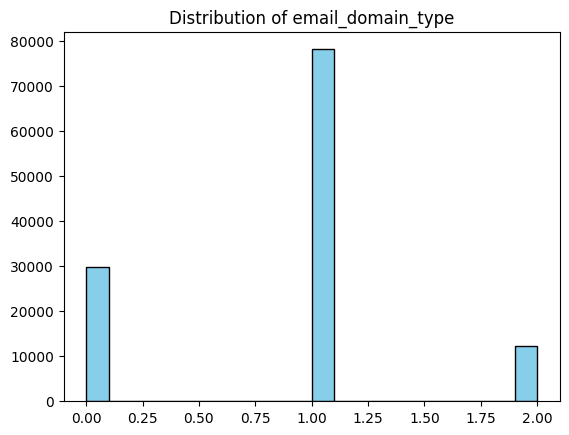

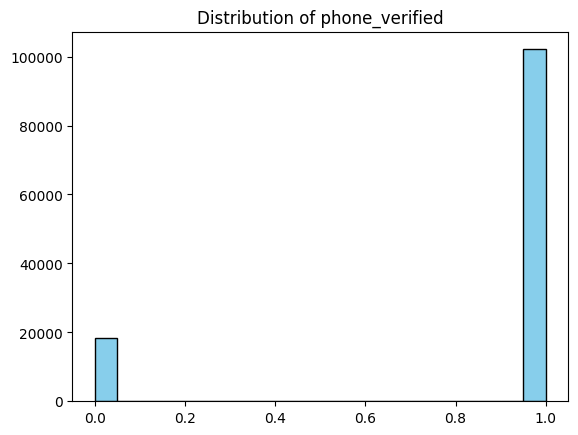

In [108]:
for col in df.columns:
    if col not in exclude_cols:
        plt.figure()
        plt.hist(df[col].astype(float), bins=20, color="skyblue", edgecolor="black")
        plt.title(f"Distribution of {col}")
        plt.show()

In [109]:
#considering Woe and log transformation can reduce reduce the effect of outliers and skewness in the data during feature engineering, we will remove outliers after feature engineering.